In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [269]:
data = pd.read_csv(r"coffeesales.csv")
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [270]:
# check data structure
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 405.1 KB


In [271]:
data.isna().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [272]:
# change 'date' and 'datetime' dtypes
data.date = pd.to_datetime(data.date)

In [273]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   str           
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 369.6 KB


In [274]:
data.datetime = pd.to_datetime(data.datetime)

In [275]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 287.9 KB


In [276]:
data.describe()

,date,datetime,money
count,3636,3636,3636.000000
mean,2024-09-30 11:56:02.376237,2024-10-01 02:35:30.535053,31.746859
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,18.120000
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750,27.920000
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500,32.820000
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750,35.760000
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,40.000000
std,NaN,NaN,4.919926


In [277]:
data.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='str')

In [278]:
data.cash_type.unique()

<ArrowStringArray>
['card', 'cash']
Length: 2, dtype: str

In [279]:
data.coffee_name.unique()

<ArrowStringArray>
[              'Latte',       'Hot Chocolate',           'Americano',
 'Americano with Milk',               'Cocoa',             'Cortado',
            'Espresso',          'Cappuccino']
Length: 8, dtype: str

In [280]:
data.value_counts()

date        datetime                 cash_type  card                 money  coffee_name  
2024-03-01  2024-03-01 10:15:50.520  card       ANON-0000-0000-0001  38.70  Latte            1
            2024-03-01 12:19:22.539  card       ANON-0000-0000-0002  38.70  Hot Chocolate    1
            2024-03-01 12:20:18.089  card       ANON-0000-0000-0002  38.70  Hot Chocolate    1
            2024-03-01 13:46:33.006  card       ANON-0000-0000-0003  28.90  Americano        1
            2024-03-01 13:48:14.626  card       ANON-0000-0000-0004  38.70  Latte            1
                                                                                            ..
2025-03-23  2025-03-23 10:34:54.894  card       ANON-0000-0000-1158  35.76  Cappuccino       1
            2025-03-23 14:43:37.362  card       ANON-0000-0000-1315  35.76  Cocoa            1
            2025-03-23 14:44:16.864  card       ANON-0000-0000-1315  35.76  Cocoa            1
            2025-03-23 15:47:28.723  card       ANON-00

In [281]:
data.date.nunique()

381

In [282]:
df = data.groupby(['date','coffee_name'])['money'].sum().reset_index()
df

,date,coffee_name,money
0,2024-03-01,Americano,28.90
1,2024-03-01,Americano with Milk,135.20
2,2024-03-01,Cocoa,38.70
3,2024-03-01,Hot Chocolate,116.10
4,2024-03-01,Latte,77.40
...,...,...,...
1706,2025-03-22,Latte,35.76
1707,2025-03-23,Americano,25.96
1708,2025-03-23,Cappuccino,35.76
1709,2025-03-23,Cocoa,71.52


In [283]:
df.loc[df.money.idxmax()]

date           2024-05-23 00:00:00
coffee_name             Cappuccino
money                       339.48
Name: 317, dtype: object

In [284]:
df[df.money == df.money.max()]

,date,coffee_name,money
317,2024-05-23,Cappuccino,339.48


In [285]:
df.loc[df.groupby('date')['money'].idxmax()][['date','coffee_name','money']]

,date,coffee_name,money
1,2024-03-01,Americano with Milk,135.20
6,2024-03-02,Americano with Milk,101.40
13,2024-03-03,Latte,78.70
16,2024-03-04,Latte,77.40
19,2024-03-05,Hot Chocolate,154.80
...,...,...,...
1680,2025-03-19,Americano,207.68
1688,2025-03-20,Americano,207.68
1700,2025-03-21,Latte,214.56
1702,2025-03-22,Americano with Milk,185.16


In [286]:
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [287]:
# get daily sales value
daily_sales = data.groupby('date')['money'].sum().reset_index()
daily_sales

,date,money
0,2024-03-01,396.30
1,2024-03-02,228.10
2,2024-03-03,349.10
3,2024-03-04,135.20
4,2024-03-05,338.50
...,...,...
376,2025-03-19,623.56
377,2025-03-20,597.60
378,2025-03-21,636.80
379,2025-03-22,365.42


<Axes: xlabel='date', ylabel='money'>

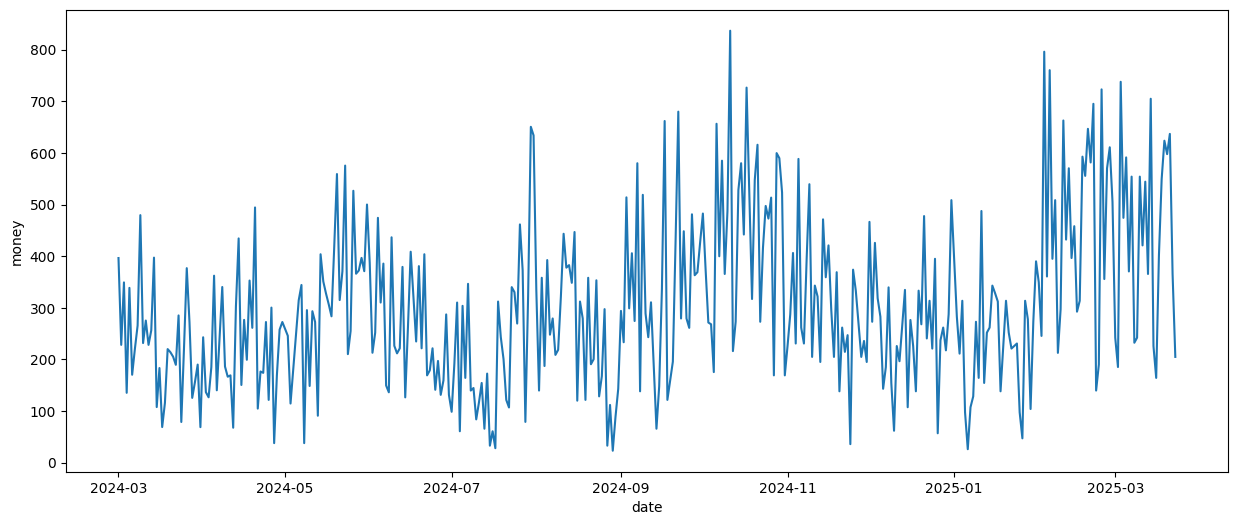

In [288]:
plt.figure(figsize=(15,6))
sns.lineplot(x='date', y='money', data=daily_sales)

<Axes: xlabel='date', ylabel='Count'>

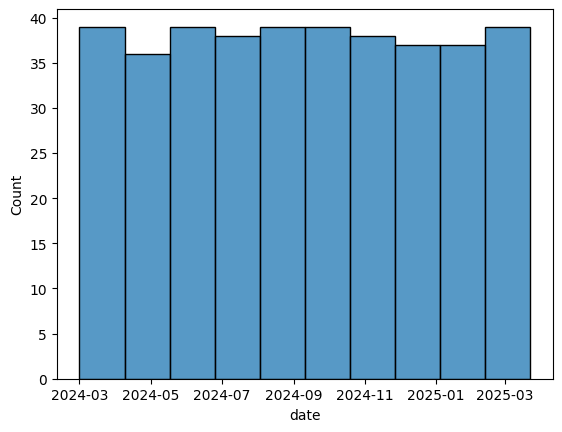

In [289]:
sns.histplot(x='date', data=daily_sales)

<Axes: xlabel='date', ylabel='money'>

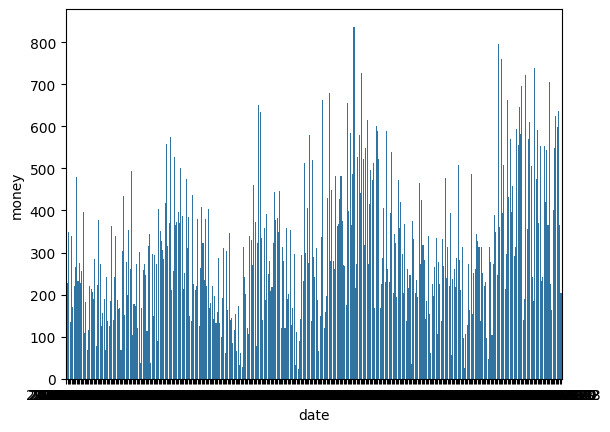

In [290]:
sns.barplot(x='date', y='money', data=daily_sales)

<Axes: xlabel='date', ylabel='money'>

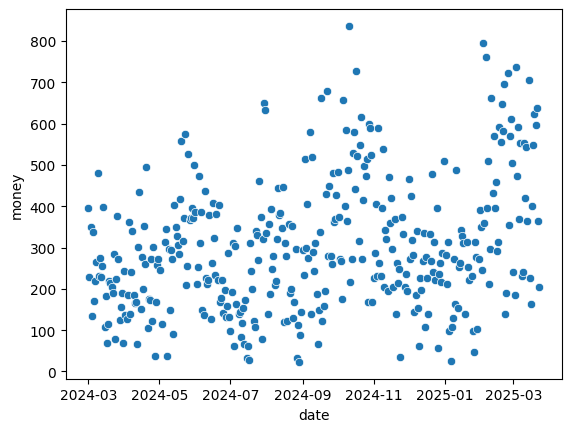

In [291]:
sns.scatterplot(x='date',y='money', data=daily_sales)

In [292]:
daily_sales.describe()

,date,money
count,381,381.000000
mean,2024-09-10 07:56:13.228346,302.970026
min,2024-03-01 00:00:00,23.020000
25%,2024-06-07 00:00:00,187.120000
50%,2024-09-10 00:00:00,276.280000
75%,2024-12-15 00:00:00,389.920000
max,2025-03-23 00:00:00,836.660000
std,NaN,159.816227


<Axes: xlabel='date', ylabel='money'>

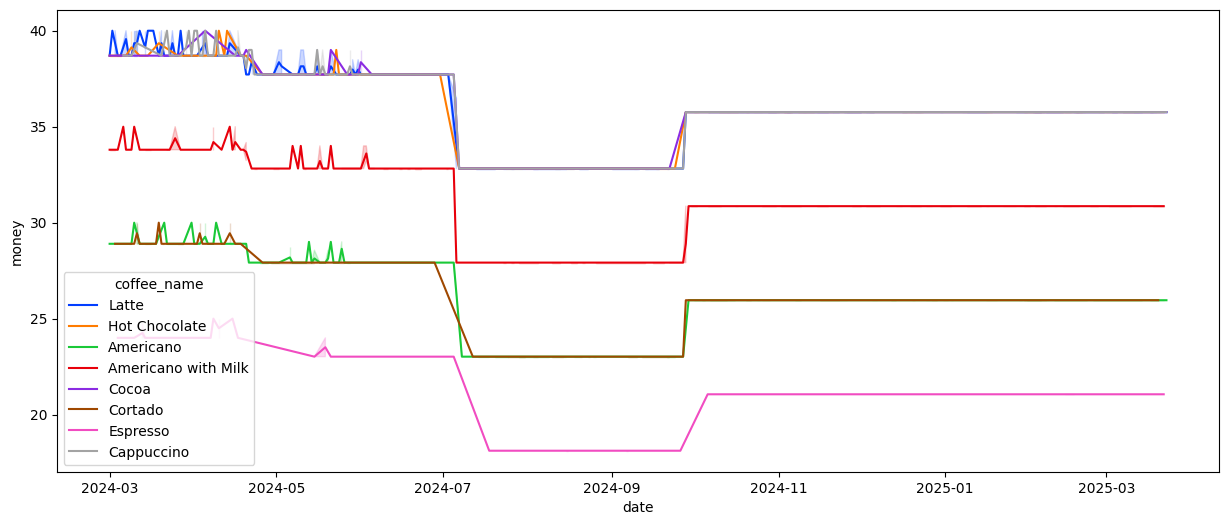

In [293]:
plt.figure(figsize=(15,6))
sns.lineplot(x='date',y='money', data=data, hue='coffee_name', palette='bright')

<Axes: xlabel='date', ylabel='Density'>

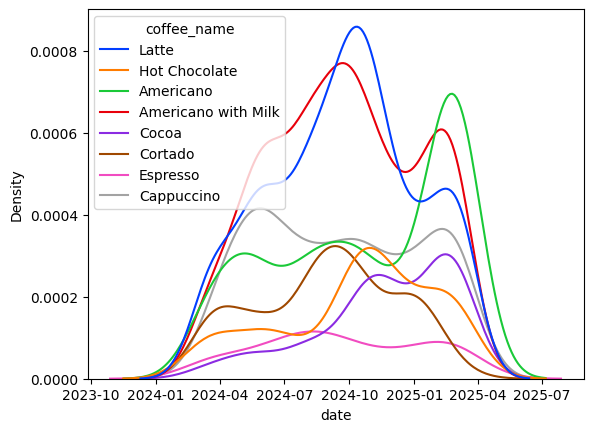

In [294]:
sns.kdeplot(x='date', data=data, hue='coffee_name', palette='bright')

In [295]:
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


<Axes: ylabel='money'>

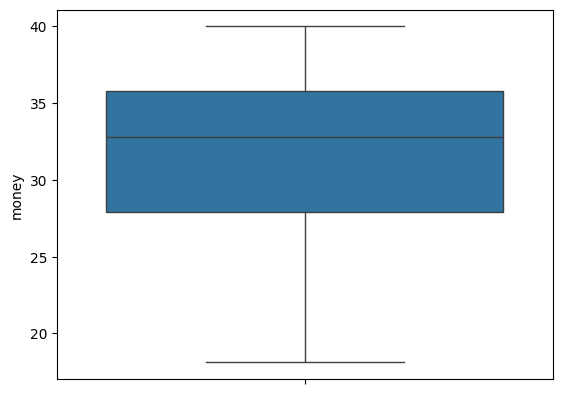

In [296]:
sns.boxplot(y='money', data=data)

<Axes: ylabel='money'>

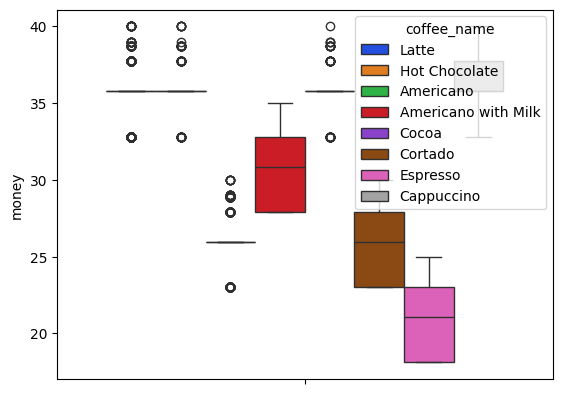

In [297]:
sns.boxplot(y='money', data=data, hue='coffee_name', palette='bright')

# Coffee Analysis


In [298]:
coffee_counts = data['coffee_name'].value_counts()
coffee_counts

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

In [299]:
print("Best selling coffee: ", coffee_counts.index[0])

Best selling coffee:  Americano with Milk


In [300]:
print("Number of best sales: ", coffee_counts.values[0])

Number of best sales:  824


In [301]:
coffee_counts.iloc[0]

np.int64(824)

In [302]:
print("Least selling coffee: ", coffee_counts.index[-1])

Least selling coffee:  Espresso


In [303]:
print("Least sell numbers:", coffee_counts.values[-1])

Least sell numbers: 134


In [306]:
# coffee sales percentage
((coffee_counts / coffee_counts.sum()) *100 ).round(2)

coffee_name
Americano with Milk    22.66
Latte                  21.51
Americano              15.90
Cappuccino             13.78
Cortado                 8.03
Hot Chocolate           7.76
Cocoa                   6.68
Espresso                3.69
Name: count, dtype: float64

In [307]:
# coffee sales percentage
for coffee, count in coffee_counts.items():
    percent = (count / coffee_counts.sum()) *100
    print(f"{coffee}: {percent:.2f}%")


Americano with Milk: 22.66%
Latte: 21.51%
Americano: 15.90%
Cappuccino: 13.78%
Cortado: 8.03%
Hot Chocolate: 7.76%
Cocoa: 6.68%
Espresso: 3.69%


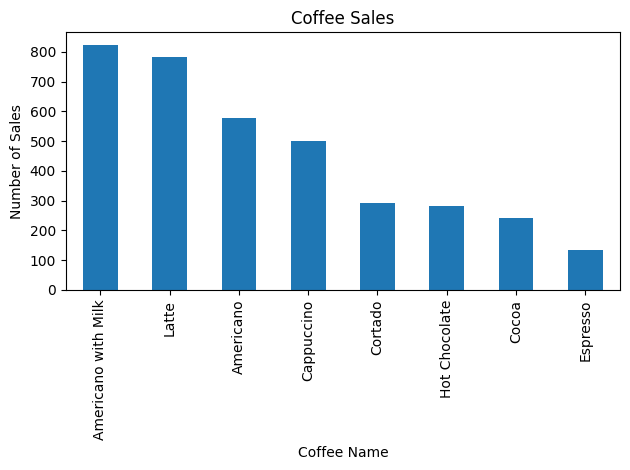

In [308]:
coffee_counts.plot(kind='bar')
plt.title("Coffee Sales")
plt.xlabel("Coffee Name")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()

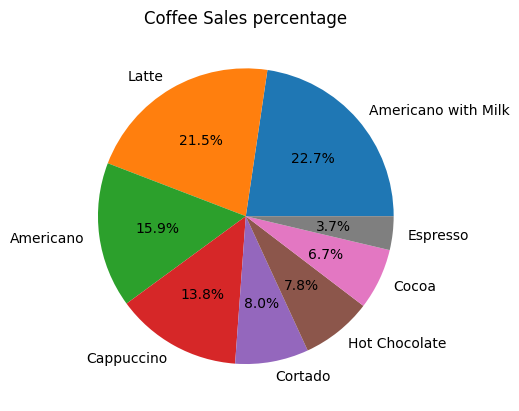

In [309]:
# Pie chart
plt.pie(coffee_counts, labels=coffee_counts.index, autopct='%1.1f%%')
plt.title("Coffee Sales percentage")
plt.show()

# Money Analysis

In [310]:
max_sales = data['money'].max()
max_sales

np.float64(40.0)

In [311]:
min_sales = data.money.min()
min_sales

np.float64(18.12)

In [312]:
data.describe()

,date,datetime,money
count,3636,3636,3636.000000
mean,2024-09-30 11:56:02.376237,2024-10-01 02:35:30.535053,31.746859
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,18.120000
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750,27.920000
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500,32.820000
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750,35.760000
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,40.000000
std,NaN,NaN,4.919926


In [313]:
data.money.agg(['min','max','mean','median','sum','std'])

min           18.120000
max           40.000000
mean          31.746859
median        32.820000
sum       115431.580000
std            4.919926
Name: money, dtype: float64

# Outlier Detection

<Axes: ylabel='money'>

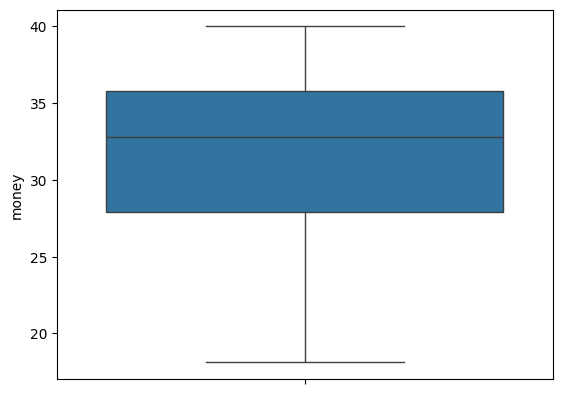

In [314]:
sns.boxplot(y='money', data=data)

In [315]:
# boxplot show 'money' --  negative skewness

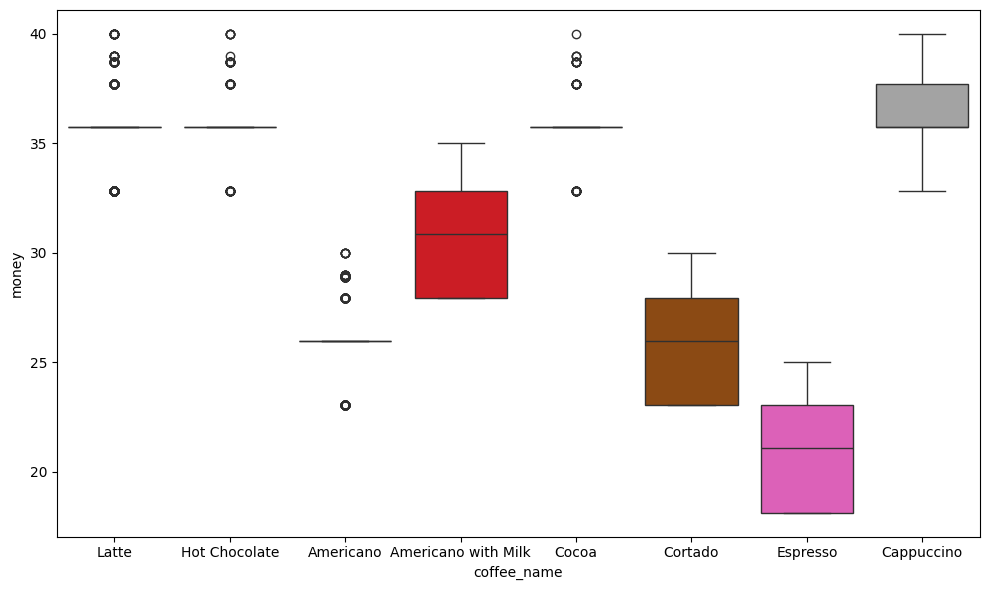

In [316]:
plt.figure(figsize=(10,6))
sns.boxplot(y='money', x='coffee_name', data=data, hue='coffee_name', palette='bright')
plt.tight_layout()

In [317]:
# outlier exits: 'hot chocolate', 'americano', 'cocoa'
# some has : negative skewness

In [318]:
# 'money' column examined for potential outlier using IQR method
q1 = data['money'].quantile(0.25)
q3 = data['money'].quantile(0.75)
iqr = q3 - q1
print(f"Quartile first: {q1}")
print(f"Quartile third: {q3}")
print(f"IQR: {iqr}")


Quartile first: 27.92
Quartile third: 35.76
IQR: 7.839999999999996


In [319]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")


Lower bound: 16.160000000000007
Upper bound: 47.519999999999996


In [320]:
outliers = data[(data['money'] < lower_bound) | (data['money'] > upper_bound)]
print(f"Number of outliers : {outliers.shape[0]}")

Number of outliers : 0


In [321]:
# using IQR method, no outliers were detected in the money column. This indicates that the sale amount
# fall within the expected range and there are no unusual high or low tranactions values

Text(0.5, 1.0, 'Boxplot of Sales Amount')

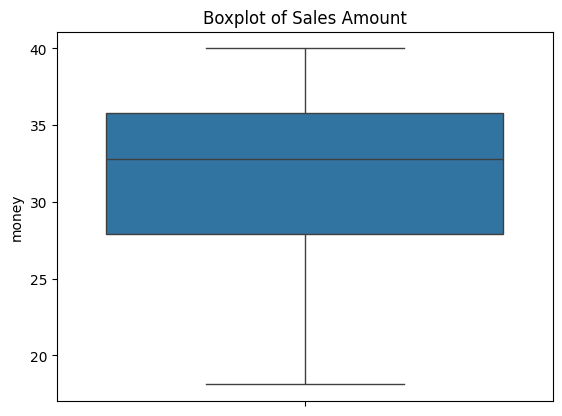

In [322]:
sns.boxplot(y=data.money, data=data)
plt.title("Boxplot of Sales Amount")

In [323]:
# detect outlier using zscore method
from scipy import stats

In [324]:
data['zscore'] = stats.zscore(data.money)

In [325]:
data.head()

,date,datetime,cash_type,card,money,coffee_name,zscore
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,1.413456
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,-0.578718
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,1.413456


In [326]:
# make all values abs()
data['zscore'] = abs(data.zscore)

In [327]:
data.head()

,date,datetime,cash_type,card,money,coffee_name,zscore
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,1.413456
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,0.578718
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,1.413456


In [328]:
# zscore values lies between -3 & 3, select value below 3 
df = data.zscore <= 3

In [329]:
data.shape

(3636, 7)

In [330]:
df.shape

(3636,)

In [331]:
# from zscore method : no outliers detected

In [332]:
# Detect outliers using mean and std method
mean_sales = data.money.mean()
std_sales = data.money.std()

In [333]:
print("Sales mean: ", mean_sales)
print("Sales std: ", std_sales)

Sales mean:  31.74685918591859
Sales std:  4.919925803555431


In [334]:
lower_limit = mean_sales - 3 * std_sales
upper_limit = mean_sales + 3 * std_sales
print("Lower limit : ", lower_limit)
print("Upper limit : ", upper_limit)

Lower limit :  16.9870817752523
Upper limit :  46.50663659658488


In [335]:
outlier_mstd = data[(data.money < lower_limit) | (data.money > upper_limit)]
print("Outliers :", outlier_mstd.shape[0])

Outliers : 0


In [336]:
# from 'mean and std' method as well no outliers detected 

In [337]:
revenue_by_coffee = data.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
revenue_by_coffee

coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Name: money, dtype: float64

Text(0.5, 1.0, 'Revenue by Coffee Type')

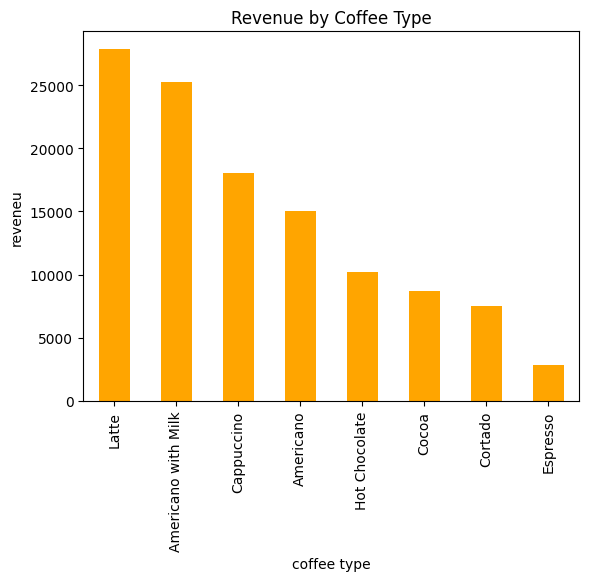

In [338]:
revenue_by_coffee.plot(kind='bar', color='orange', xlabel='coffee type', ylabel='reveneu')
plt.title("Revenue by Coffee Type")

In [339]:
# Observation: High sales transaction is 'Americano with milk', but high revenu is 'lattee'
# Higher priced products can generate more revenue even with less trasnactions.


In [340]:
# pie plot - reveneu
sum_revenue = data.money.sum()
revenue_percentage = ((revenue_by_coffee / sum_revenue) * 100).round(2)
revenue_percentage

coffee_name
Latte                  24.14
Americano with Milk    21.89
Cappuccino             15.62
Americano              13.05
Hot Chocolate           8.81
Cocoa                   7.52
Cortado                 6.53
Espresso                2.44
Name: money, dtype: float64

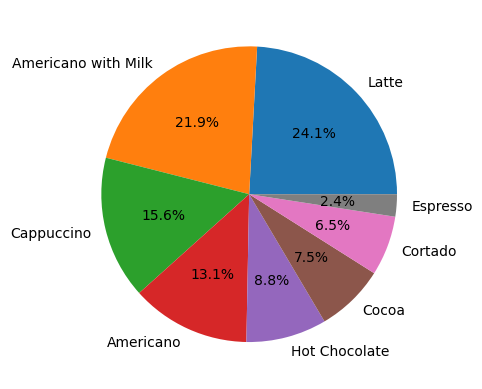

In [341]:
plt.pie(revenue_percentage, labels=revenue_percentage.index, autopct='%1.1f%%')
plt.show()

# Payment method analysis

In [342]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name,zscore
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,1.413456
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456


In [343]:
data.cash_type.unique()

<ArrowStringArray>
['card', 'cash']
Length: 2, dtype: str

In [344]:
data.cash_type.value_counts()

cash_type
card    3547
cash      89
Name: count, dtype: int64

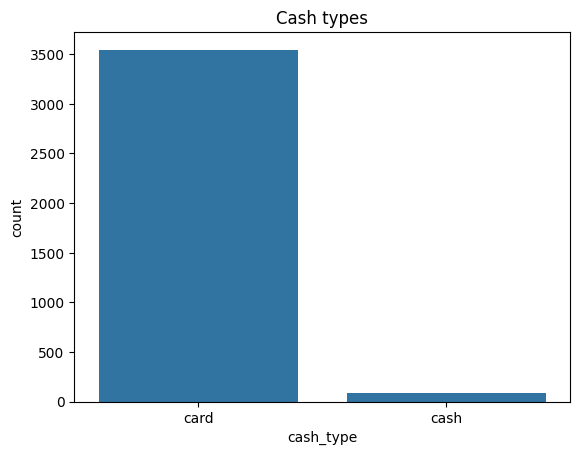

In [346]:
sns.barplot(data.cash_type.value_counts())
plt.title("Cash types")
plt.show()

In [349]:
total_cash_type = data.cash_type.value_counts().sum()
cash_type_percent = (data['cash_type'].value_counts() / total_cash_type * 100).round(2)
cash_type_percent

cash_type
card    97.55
cash     2.45
Name: count, dtype: float64

<Axes: title={'center': 'Cash type percentage'}>

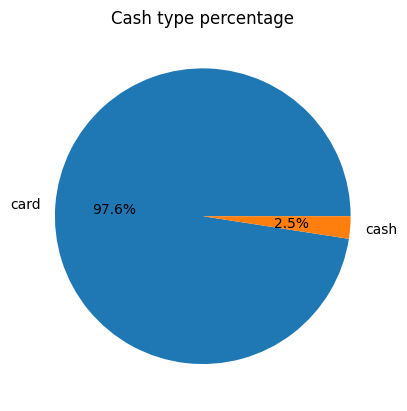

In [351]:
cash_type_percent.plot(kind='pie', autopct='%1.1f%%', title='Cash type percentage')

In [353]:
cash_type_revenue = data.groupby('cash_type')['money'].sum()
cash_type_revenue

cash_type
card    112245.58
cash      3186.00
Name: money, dtype: float64

In [354]:
cash_type_revenue.values.sum()

np.float64(115431.58)

<Axes: title={'center': 'Revenue by Cash type'}>

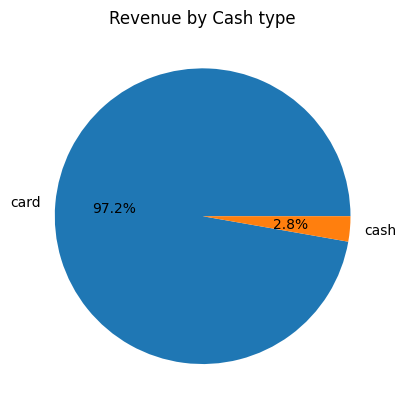

In [356]:
cash_type_revenue.plot(kind='pie', autopct='%1.1f%%', title='Revenue by Cash type')

<Axes: title={'center': 'Cash type revenue'}, xlabel='Cash type', ylabel='revenue'>

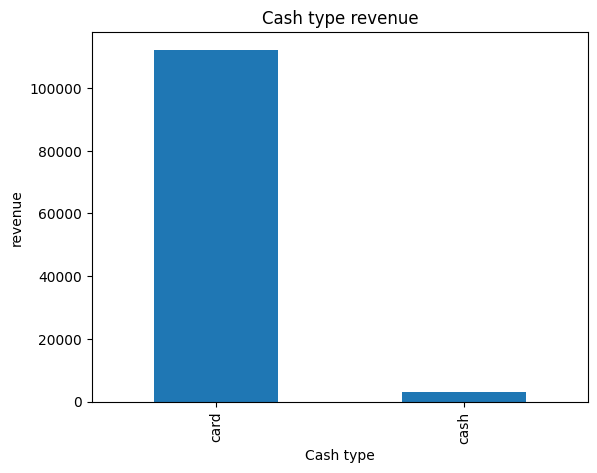

In [358]:
cash_type_revenue.plot(kind='bar', xlabel='Cash type', ylabel='revenue', title='Cash type revenue')

In [359]:
# card payment transcation: 3547 -- revenue: 97.2% --112245.58
# Cash payment transcation: 89 ---reveneu: 2.45 % --3186
# Card payment dominated both transcation and revenue

# Date Analysis

In [360]:
print("Start date: ", data.date.min())
print("End date: ", data.date.max())

Start date:  2024-03-01 00:00:00
End date:  2025-03-23 00:00:00


In [361]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
 6   zscore       3636 non-null   float64       
dtypes: datetime64[us](2), float64(2), str(3)
memory usage: 316.3 KB


In [367]:
data.groupby('date').size()

date
2024-03-01    11
2024-03-02     7
2024-03-03    10
2024-03-04     4
2024-03-05     9
              ..
2025-03-19    21
2025-03-20    20
2025-03-21    20
2025-03-22    12
2025-03-23     6
Length: 381, dtype: int64

<Axes: title={'center': 'Daily sales'}, xlabel='Date', ylabel='Number of sales'>

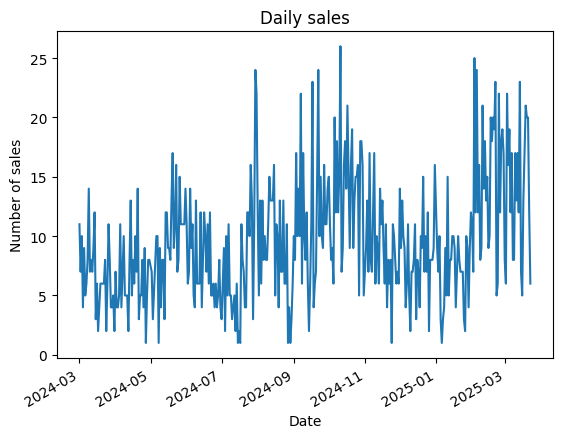

In [372]:
daily_sales_count = data.groupby('date').size()
daily_sales_count.plot(kind='line', title='Daily sales', xlabel='Date', ylabel='Number of sales')

In [370]:
daily_revenue = data.groupby('date')['money'].sum()
daily_revenue

date
2024-03-01    396.30
2024-03-02    228.10
2024-03-03    349.10
2024-03-04    135.20
2024-03-05    338.50
               ...  
2025-03-19    623.56
2025-03-20    597.60
2025-03-21    636.80
2025-03-22    365.42
2025-03-23    204.76
Name: money, Length: 381, dtype: float64

<Axes: title={'center': 'Daily Revenue'}, xlabel='date', ylabel='revenue'>

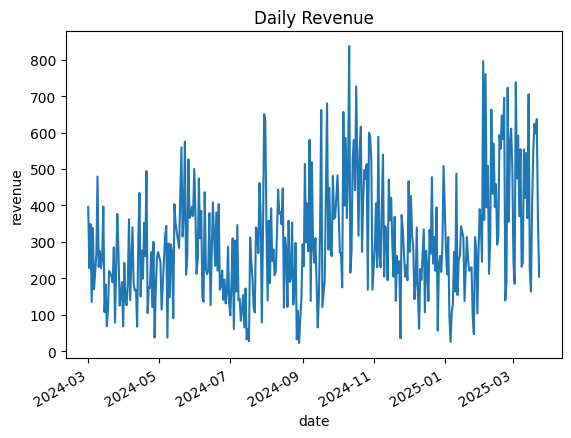

In [373]:
daily_revenue.plot(kind='line', title='Daily Revenue', xlabel='date', ylabel='revenue')

In [375]:
print("maximum sales: ", daily_sales_count.max())

maximum sales:  26


In [377]:
daily_sales_count

date
2024-03-01    11
2024-03-02     7
2024-03-03    10
2024-03-04     4
2024-03-05     9
              ..
2025-03-19    21
2025-03-20    20
2025-03-21    20
2025-03-22    12
2025-03-23     6
Length: 381, dtype: int64

In [381]:
print('Date with maximum sales:', daily_sales_count.idxmax())

Date with maximum sales: 2024-10-11 00:00:00


In [382]:
print("Maximum revenue: ", daily_revenue.max())

Maximum revenue:  836.66


In [383]:
print("Date with max revenue: ", daily_revenue.idxmax())

Date with max revenue:  2024-10-11 00:00:00


In [384]:
# Observation : highest sales day and highest revenue day is : 2024-10-11. 

# Date time Analysis

In [388]:
data.head()

,date,datetime,cash_type,card,money,coffee_name,zscore
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,1.413456
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,0.578718
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,1.413456


In [386]:
data['datetime'].dt.hour

0       10
1       12
2       12
3       13
4       13
        ..
3631    10
3632    14
3633    14
3634    15
3635    18
Name: datetime, Length: 3636, dtype: int32

In [393]:
data.groupby(data['datetime'].dt.hour).size()

datetime
6       5
7      91
8     235
9     247
10    349
11    294
12    249
13    227
14    228
15    245
16    283
17    244
18    220
19    235
20    171
21    197
22    116
dtype: int64

In [390]:
hourly_sales = data.groupby(data['datetime'].dt.hour).size()
print("Business hour: ", hourly_sales.idxmax())
print("Max sales: ", hourly_sales.max())

Business hour:  10
Max sales:  349


<Axes: title={'center': 'Hourly sales distribution'}, xlabel='Hour', ylabel='sales'>

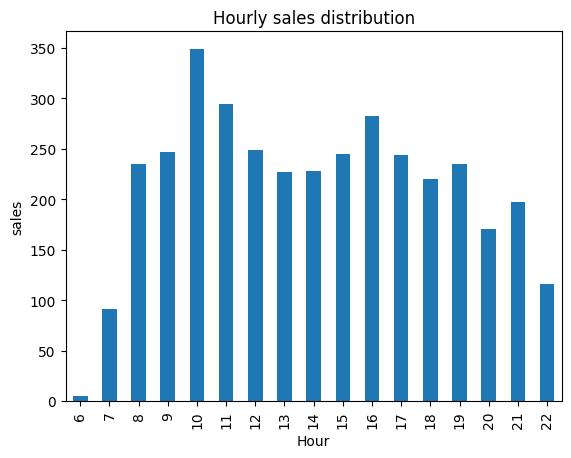

In [395]:
hourly_sales.plot(kind='bar', title='Hourly sales distribution', xlabel='Hour', ylabel='sales')

In [401]:
hourly_revenue = data.groupby(data['datetime'].dt.hour)['money'].sum()
hourly_revenue

datetime
6       149.40
7      2940.02
8      7017.88
9      7429.28
10    10994.52
11     8849.10
12     7668.62
13     7108.76
14     7265.80
15     7789.02
16     9221.60
17     7925.00
18     7235.60
19     7966.96
20     5656.92
21     6465.94
22     3747.16
Name: money, dtype: float64

In [402]:
print("Business Hour high revenue: ", hourly_revenue.idxmax())

Business Hour high revenue:  10


In [403]:
print("Hourly high revenue: ", hourly_revenue.max())

Hourly high revenue:  10994.52


<Axes: title={'center': 'Hourly revenue'}, xlabel='Hour', ylabel='revenue'>

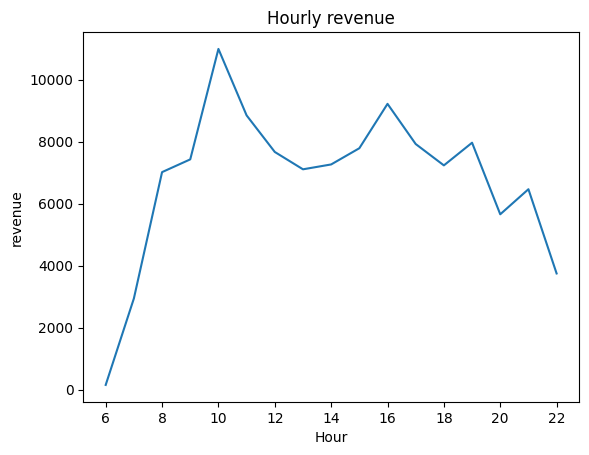

In [405]:
hourly_revenue.plot(kind='line', title='Hourly revenue', xlabel='Hour', ylabel='revenue')

In [406]:
def get_time_period(hour):
    if 6 <= hour <=12:
        return 'morning'
    elif 12 <= hour <=17:
        return 'afternoon'
    elif 17 <=hour <=22:
        return 'evening'
    else:
        return 'night'


In [408]:
data['time_period'] = data['datetime'].dt.hour.apply(get_time_period)

In [409]:
data.head()

,date,datetime,cash_type,card,money,coffee_name,zscore,time_period
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,1.413456,morning
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456,morning
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,1.413456,morning
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,0.578718,afternoon
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,1.413456,afternoon


In [410]:
time_period_sales = data.groupby('time_period').size()
time_period_sales

time_period
afternoon    1227
evening       939
morning      1470
dtype: int64

<Axes: xlabel='time_period'>

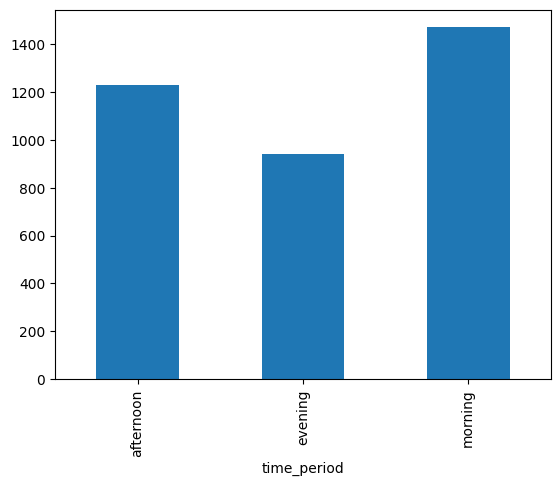

In [413]:
time_period_sales.plot(kind='bar')

In [415]:
time_period_revenue = data.groupby('time_period')['money'].sum()
time_period_revenue

time_period
afternoon    39310.18
evening      31072.58
morning      45048.82
Name: money, dtype: float64

<Axes: xlabel='time_period'>

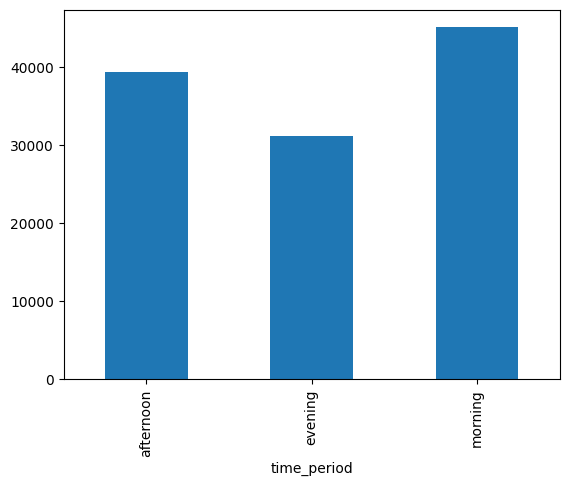

In [416]:
time_period_revenue.plot(kind='bar')

In [420]:
daily_sales_analysis = data.groupby(['time_period','coffee_name'])['money'].sum().reset_index()
daily_sales_analysis

,time_period,coffee_name,money
0,afternoon,Americano,5803.48
1,afternoon,Americano with Milk,7390.10
2,afternoon,Cappuccino,6399.66
3,afternoon,Cocoa,2906.00
4,afternoon,Cortado,2160.70
5,afternoon,Espresso,1137.74
6,afternoon,Hot Chocolate,3670.54
7,afternoon,Latte,9841.96
8,evening,Americano,1984.82
9,evening,Americano with Milk,5911.22


<Axes: xlabel='time_period', ylabel='money'>

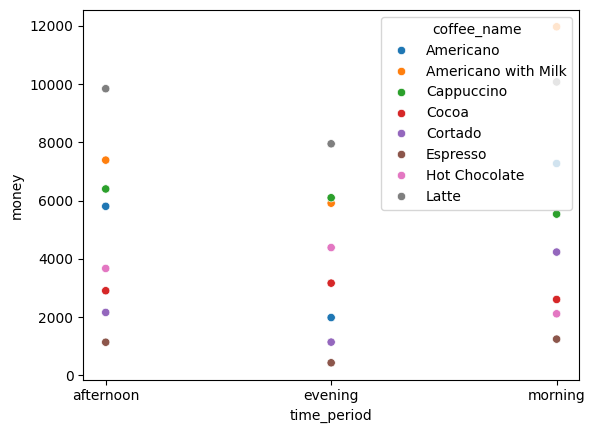

In [421]:
sns.scatterplot(data=daily_sales_analysis, x='time_period', y='money', hue='coffee_name')

<Axes: xlabel='time_period', ylabel='money'>

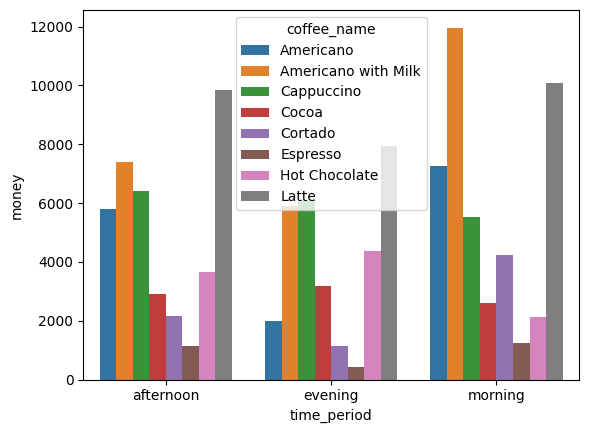

In [422]:
sns.barplot(data=daily_sales_analysis, x='time_period', y='money', hue='coffee_name')

<Axes: xlabel='time_period', ylabel='money'>

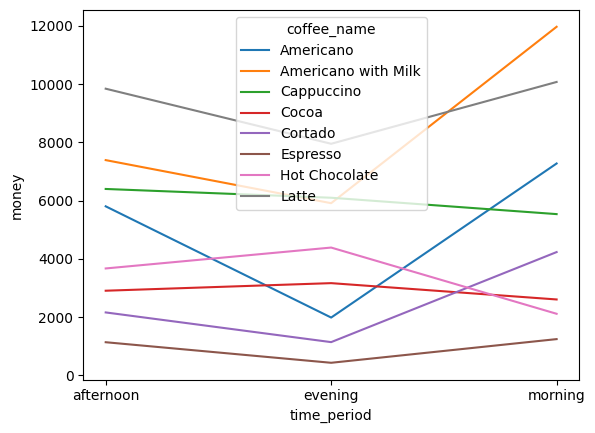

In [426]:
sns.lineplot(data=daily_sales_analysis, x='time_period', y='money', hue='coffee_name')

<Axes: xlabel='money', ylabel='Count'>

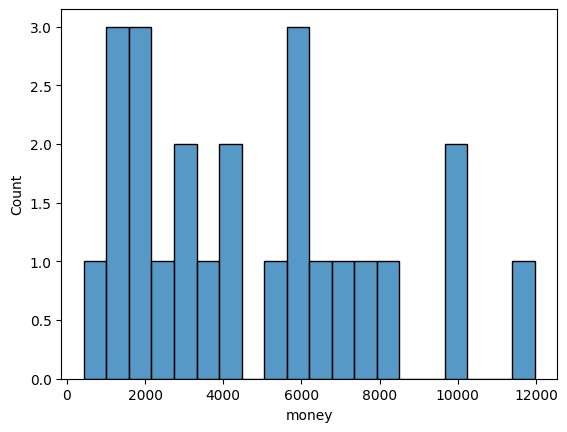

In [434]:
sns.histplot(data=daily_sales_analysis, x='money', bins=20)

<Axes: xlabel='money', ylabel='Density'>

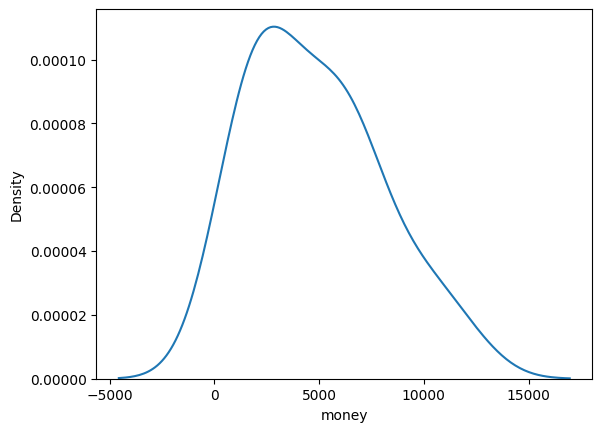

In [436]:
sns.kdeplot(data=daily_sales_analysis, x='money')

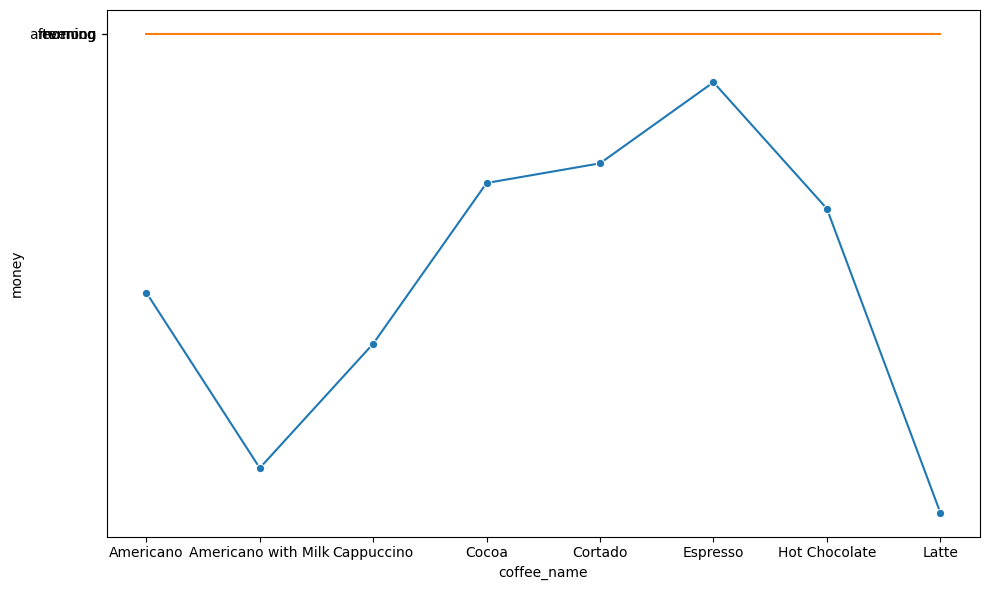

In [446]:
plt.figure(figsize=(10,6))
sns.lineplot(data=daily_sales_analysis, x='coffee_name', y='money', errorbar=None, marker='o')
sns.lineplot(data=daily_sales_analysis, x='coffee_name', y='time_period', errorbar=None)

plt.tight_layout()
plt.show()

<Axes: xlabel='time_period', ylabel='money'>

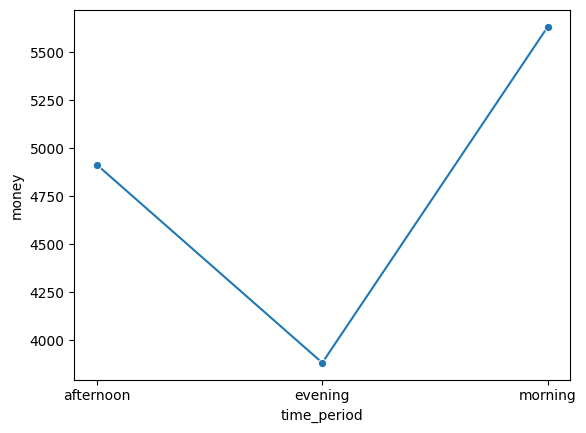

In [449]:
sns.lineplot(data=daily_sales_analysis, x='time_period', y='money', errorbar=None, marker='o')